<h1 style="text-align: center;">[Sinarmas Land]</h1>
<h3 style="text-align: center;">[Mikha, Hane, Nadya]</h3>

---

## **Section 1. Business Context**

**1.1 Context**

Sinarmas Land telah meredefinisi konsep pengembangan properti di Indonesia dengan tidak sekadar membangun perumahan, melainkan merancang Kota Mandiri terpadu (Township). Pendapatan ini bersumber dari Iuran Pemeliharaan Lingkungan (IPL), tagihan utilitas (air bersih kawasan), serta penyewaan area komersial.

Untuk mempertahankan standar fasilitas dan layanan prima setara hotel bintang lima, mulai dari keamanan 24 jam hingga pemeliharaan infrastruktur.Tim Township Management sangat bergantung pada kelancaran arus kas (cashflow) dari pembayaran IPL bulanan warga.

**Namun, operasional raksasa ini saat ini menghadapi dua tantangan besar:**

1. Tingginya Properti Kosong (Investasi): Banyak unit properti dibeli murni untuk investasi (capital gain) dan dibiarkan kosong. Pemilik yang berdomisili di luar kota atau luar negeri sering kali mengabaikan tagihan, sehingga menciptakan tren Non-Performing Invoice (tunggakan) yang terus merangkak naik. Akibatnya, rumah tidak terawat, estetika kawasan rusak, dan SML terpaksa mensubsidi biaya operasional dari kantong perusahaan induk.  

2. Kerapian Data & Infrastruktur ERP yang Lemah: Sistem pencatatan internal (ERP) terindikasi memiliki banyak celah (bug logika) dan rentan terhadap human error. Mulai dari salah ketik angka meteran air yang memicu lonjakan tagihan tak masuk akal, ketidakseragaman pencatatan metode pembayaran, hingga data kontak konsumen yang tidak lengkap.  Analisis data secara mendalam dan pembersihan data (data cleansing) mutlak diperlukan untuk menyehatkan kembali pembukuan Estate Management serta menjaga nilai jual merek (brand value) properti SML di mata investor. 

**1.2 Problem Statements**

**Masalah Utama (Core Problem)Membengkaknya defisit operasional pada Township Management akibat tingginya akumulasi tunggakan IPL dari properti berstatus kosong (vacant), yang diperparah oleh inefisiensi sistem pencatatan tagihan utilitas serta rendahnya kualitas data pada sistem billing.**  

**Masalah Turunan (Specific Issues)**

- **Aspek Finansial & Operasional:**

- Kawasan (Township/Cluster) mana saja yang memiliki rasio tunggakan IPL tertinggi, dan seberapa besar kontribusi dari rumah berstatus kosong (vacant) terhadap total tunggakan tersebut?   

- Berapa estimasi potensi pendapatan yang hilang atau tertunda (loss/delayed revenue) akibat warga yang menunggak secara kronis (lebih dari 6 bulan berturut-turut)?  

- **Aspek Kualitas & Integritas Data (Data Quality):**
    - Seberapa besar tingkat inkonsistensi (data anomaly) pada kolom Payment Method akibat standardisasi input yang lemah?  
    - Berapa persentase data pemilik rumah yang kehilangan informasi kontak (colum Missing Values pada nomor telepon) yang menghambat efektivitas tim Collection? 

- **Aspek Bug Sistem & Logika Bisnis (System Anomalies):**
    - Ditemukan anomali fatal (logical error) di mana status tagihan telah lunas ('Paid'), namun tanggal pembayaran tercatat bertahun-tahun sebelum tanggal serah terima kunci (handover date) dilakukan.  
    - Tingginya volume data luar biasa (outliers) pada pemakaian air warga akibat kesalahan input manual lapangan yang berujung pada komplain salah tagih.  

**1.3 Key Objective**

|**Strategi**|**Deskripsi & Tujuan Operasional**|
| --- | --- |
|Revenue Recovery| Membangun dashboard aging schedule (umur piutang) untuk memfokuskan tim Collection mengejar pemilik rumah investasi yang menunggak miliaran rupiah.|
|Utility System Patching| Menambahkan fungsi validasi pada aplikasi petugas catat meteran, sehingga input pemakaian air yang melonjak >300% dari bulan sebelumnya akan otomatis diblokir untuk verifikasi ulang.|
|Data Cleansing| Menstandarisasi penamaan metode pembayaran agar tim rekonsiliasi Finance tidak perlu begadang tiap akhir bulan mencocokkan mutasi rekening bank.|
|Anti-Fraud/Bug Fix| Menutup bug logika ERP yang menerbitkan dan menerima pembayaran invoice untuk unit yang tanahnya saja bahkan belum dibangun.|


## **Section 2. Data Understanding**

### 2.1 General Information

**Skala Dataset**

Dataset terdiri dari 3 tabel utama dengan total sekitar 300.000 baris data tagihan bulanan.

sml_clusters.csv → dimensi cluster/kawasan.

sml_units.csv → dimensi unit rumah/ruko.

sml_ipl_billings.csv → fakta tagihan bulanan.

**Tujuan Pengumpulan Data**

Data ini dikumpulkan oleh Estate Management Sinarmas Land untuk mendukung operasional township (BSD City, Kota Wisata, Grand Wisata, NavaPark). Fokusnya adalah:

Penagihan IPL (Iuran Pemeliharaan Lingkungan).

Tagihan utilitas (air bersih).

Monitoring kepatuhan pembayaran warga.

**Karakteristik Data**

Granularitas: data bulanan per unit rumah.

Relasi antar tabel:

cluster_id menghubungkan unit dengan cluster.

unit_id menghubungkan unit dengan tagihan bulanan.

Variasi data: mencakup informasi demografi (pemilik, kontak), status rumah (vacant/occupied), serta transaksi finansial (invoice, payment).

**Potensi Insight**

Analisis aging schedule piutang (tunggakan IPL).

Identifikasi cluster dengan rasio tunggakan tinggi.

Validasi kualitas data (missing values, outliers, logical errors).

Deteksi fraud/anomali pada sistem ERP.

### 2.2 Feature Information

| **Dataset** | **Kolom** | **Tipe Data** | **Deskripsi** | **Relevansi Analisis** |
| --- | --- | --- | --- | --- |
| **sml_clusters.csv** | ``cluster_id`` | Integer/String | ID unik cluster | Identifikasi cluster/township untuk analisis rasio tunggakan |
|  | ``township_name`` | String | Nama kota mandiri (BSD City, Kota Wisata, dll) | Segmentasi berdasarkan township |
|  | ``cluster_category`` | Categorical String | Segmen pasar (Premium, Middle, Commercial) | Analisis perbandingan antar kategori pasar |
| **sml_units.csv** | ``unit_id`` | Integer/String | ID unik rumah/ruko | Relasi ke tagihan bulanan |
|  | ``cluster_id`` | Foreign Key | Relasi ke ``sml_clusters`` | Hubungan unit dengan cluster |
|  | ``owner_name`` | String | Nama pemilik unit | Identifikasi pemilik rumah |
|  | ``contact_number`` | String | Nomor telepon pemilik (sering kosong) | Penting untuk tim Collection, rawan missing values |
|  | ``is_vacant`` | Boolean | Status rumah kosong (True/False) | Analisis rumah investasi kosong |
|  | ``handover_date`` | Datetime | Tanggal serah terima unit | Validasi logical error (payment sebelum handover) |
| **sml_ipl_billings.csv** | ``invoice_id`` | Integer/String | Nomor tagihan unik | Identifikasi invoice |
|  | ``unit_id`` | Foreign Key | Relasi ke ``sml_units`` | Hubungan tagihan dengan unit |
|  | ``billing_month`` | Period (YYYY-MM) | Periode bulan tagihan | Analisis aging schedule piutang |
|  | ``water_usage_m3`` | Numeric (Float/Int) | Pemakaian air dalam m³ | Deteksi outlier ekstrem |
|  | ``ipl_fee`` | Numeric | Biaya standar IPL | Komponen biaya tetap |
|  | ``total_amount`` | Numeric | Total tagihan (IPL + Air + Denda) | Estimasi revenue dan tunggakan |
|  | ``payment_status`` | Categorical String | Status pembayaran (Paid, Unpaid, Overdue) | Analisis kepatuhan pembayaran |
|  | ``payment_method`` | Categorical String | Metode pembayaran (BCA VA, Tokopedia, Cash, dll) | Evaluasi standar pencatatan metode pembayaran |
|  | ``payment_date`` | Datetime | Tanggal pembayaran | Validasi logical error (Paid sebelum handover) |

### 2.3 Statistics Summary

| **Aspek** | **Temuan Awal (Estimasi/Kualitatif)** | **Relevansi Analisis** |
| --- | --- | --- |
| **Jumlah Data** | ± 300.000 baris tagihan bulanan, puluhan ribu unit rumah, ratusan cluster | Skala besar → butuh data cleaning & validasi sistematis |
| **Rumah Kosong (is_vacant)** | Proporsi signifikan unit berstatus *vacant* (investasi) | Kontributor utama tunggakan IPL |
| **Payment Status** | Banyak invoice berstatus *Unpaid* atau *Overdue* | Fokus untuk aging schedule piutang & revenue recovery |
| **Payment Method** | Tidak konsisten: “BCA VA”, “VA BCA”, “Tokped”, “Tokopedia”, “Cash”, dll | Menyulitkan rekonsiliasi Finance, perlu standardisasi |
| **Contact Number** | Persentase missing values tinggi (kolom kosong) | Hambatan bagi tim Collection dalam menagih tunggakan |
| **Water Usage (m³)** | Outlier ekstrem (misal >10.000 m³ untuk rumah kecil) | Memicu komplain salah tagih, perlu anomaly detection |
| **Logical Error (Payment Date)** | Ada kasus *Paid* sebelum *handover_date* unit | Bug ERP → indikasi fraud/ketidaksesuaian sistem |
| **Total Amount** | Variasi besar, termasuk nilai minus atau melonjak tidak wajar | Perlu validasi formula perhitungan tagihan |

## **Section 3. Data Cleaning**

### Data Preparation

In [255]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

In [256]:
df_clusters_raw = pd.read_csv('sml_clusters.csv')
df_ipl_raw = pd.read_csv('sml_ipl_billings.csv')
df_units_raw = pd.read_csv('sml_units.csv')

df_clusters = df_clusters_raw.copy()
df_ipl = df_ipl_raw.copy()
df_units = df_units_raw.copy()

print(f'Clusters    : {df_clusters.shape}')
print(f'IPL : {df_ipl.shape}')
print(f'Units   : {df_units.shape}')

Clusters    : (100, 3)
IPL : (300000, 9)
Units   : (25000, 6)


### Data Exploration

In [257]:
# Shape dan info umum — lakukan untuk ketiga tabel
print(df_clusters.shape)
df_clusters.info()

(100, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   cluster_id        100 non-null    object
 1   township_name     100 non-null    object
 2   cluster_category  100 non-null    object
dtypes: object(3)
memory usage: 2.5+ KB


In [258]:
print(df_ipl.shape)
df_ipl.info()

(300000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   invoice_id      300000 non-null  object 
 1   unit_id         300000 non-null  object 
 2   billing_month   300000 non-null  object 
 3   water_usage_m3  300000 non-null  float64
 4   ipl_base_fee    300000 non-null  int64  
 5   total_amount    300000 non-null  float64
 6   payment_status  300000 non-null  object 
 7   payment_method  209722 non-null  object 
 8   payment_date    209722 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 20.6+ MB


In [259]:
print(df_units.shape)
df_units.info()

(25000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_id         25000 non-null  object 
 1   cluster_id      25000 non-null  object 
 2   owner_name      25000 non-null  object 
 3   contact_number  20000 non-null  float64
 4   is_vacant       25000 non-null  bool   
 5   handover_date   25000 non-null  object 
dtypes: bool(1), float64(1), object(4)
memory usage: 1001.1+ KB


In [260]:
print(f"{df_clusters.shape}")
print(f"{df_ipl.shape}")
print(f"{df_units.shape}")

(100, 3)
(300000, 9)
(25000, 6)


### 3.1 Missing Values

In [261]:
print(f"total cells = {df_clusters.shape[0] * df_clusters.shape[1]}")
print(f"total empty cells = {df_clusters.isnull().sum().sum()}")
print(f"percentage of empty cells = {(df_clusters.isnull().sum().sum())/(df_clusters.shape[0] * df_clusters.shape[1]):.2%}")

total cells = 300
total empty cells = 0
percentage of empty cells = 0.00%


In [262]:
print(f"total cells = {df_ipl.shape[0] * df_ipl.shape[1]}")
print(f"total empty cells = {df_ipl.isnull().sum().sum()}")
print(f"percentage of empty cells = {(df_ipl.isnull().sum().sum())/(df_ipl.shape[0] * df_ipl.shape[1]):.2%}")

total cells = 2700000
total empty cells = 180556
percentage of empty cells = 6.69%


In [263]:
print(f"total cells = {df_units.shape[0] * df_units.shape[1]}")
print(f"total empty cells = {df_units.isnull().sum().sum()}")
print(f"percentage of empty cells = {(df_units.isnull().sum().sum())/(df_units.shape[0] * df_units.shape[1]):.2%}")

total cells = 150000
total empty cells = 5000
percentage of empty cells = 3.33%


In [264]:
# Persentase Kolom kosong pada contact_number
missing = df_units["contact_number"].isna().sum().sum()
total_row = len(df_units["contact_number"])
missing_pct = missing / total_row * 100
print(missing_pct)

20.0


In [265]:
# Melihat jumlah unit yang tidak memiliki no telp yang valid
df_units['contact_number_missing'] = df_units['contact_number'].isnull()

print(f"{df_units['contact_number_missing'].sum():,} units missing a phone number "
      f"({df_units['contact_number_missing'].mean():.1%})")

5,000 units missing a phone number (20.0%)


✍️ Analisis & Justifikasi:

Jenis missing value (MCAR / MAR / MNAR): MCAR
Kolom kosong yang harusnya berisi contact/no telp pemilik rumah dipengaruhi beberapa faktor seperti Privasi yang tidak ingin diusik dan kelupaan input no telp

**3.2 Duplicated Values**

In [266]:
df_ipl.groupby("payment_method")["unit_id"].count()

payment_method
BCA Virtual Account    23216
Cash                   23370
Credit Card            23267
KAS                    23438
Tokopedia              23238
VA BCA                 23200
bca va                 23242
cc                     23302
toped                  23449
Name: unit_id, dtype: int64

In [267]:
# Lihat semua nilai unik di payment_method beserta frekuensinya
pd.unique(df_ipl["payment_method"])

array(['Cash', nan, 'KAS', 'toped', 'BCA Virtual Account', 'Tokopedia',
       'bca va', 'cc', 'VA BCA', 'Credit Card'], dtype=object)

In [268]:
# Standarisasi payment_method
# Simpan hasil ke kolom baru: payment_method_clean
payment_method_map = {
    "Cash": "Cash",
    "KAS": "Cash",
    "Tokopedia": "Tokopedia",
    "toped": "Tokopedia",
    "BCA Virtual Account": "BCA Virtual Account",
    "bca va": "BCA Virtual Account",
    "VA BCA": "BCA Virtual Account",
    "Credit Card": "Credit Card",
    "cc": "Credit Card",
}

df_ipl["payment_method_clean"] = df_ipl["payment_method"].map(payment_method_map)

print("Before:")
print(df_ipl["payment_method"].value_counts(dropna=False))
print()
print("After:")
print(df_ipl["payment_method_clean"].value_counts(dropna=False))

Before:
payment_method
NaN                    90278
toped                  23449
KAS                    23438
Cash                   23370
cc                     23302
Credit Card            23267
bca va                 23242
Tokopedia              23238
BCA Virtual Account    23216
VA BCA                 23200
Name: count, dtype: int64

After:
payment_method_clean
NaN                    90278
BCA Virtual Account    69658
Cash                   46808
Tokopedia              46687
Credit Card            46569
Name: count, dtype: int64


In [269]:
# Penanganan duplikat invoice di billing_month yang sama
invoice_counts = df_ipl.groupby(['unit_id', 'billing_month']).size()
print(invoice_counts)

unit_id    billing_month
UNT-00001  2020-07          1
           2023-02          1
           2023-08          4
           2023-10          2
           2023-11          1
                           ..
UNT-25000  2023-11          1
           2024-01          1
           2024-06          1
           2024-08          1
           2024-11          2
Length: 238305, dtype: int64


In [270]:
# Melihat jumlah duplikasi invoice dalam satu bulan (>1 = duplikat)
print(invoice_counts.value_counts())

1    185877
2     44244
3      7209
4       878
5        88
6         7
7         2
Name: count, dtype: int64


In [271]:
# Drop invoice yang duplikat pada kolom billing_month
df_ipl_sorted = df_ipl.sort_values(
    by=['payment_status', 'invoice_id'],
    key=lambda col: col.map({'Paid': 2, 'Overdue': 1, 'Unpaid': 0}) if col.name == 'payment_status' else col
)
df_ipl_clean = df_ipl_sorted.drop_duplicates(subset=['unit_id', 'billing_month'], keep='last')

print(f"Before: {len(df_ipl):,} rows -> After: {len(df_ipl_clean):,} rows")

Before: 300,000 rows -> After: 238,305 rows


**3.3 Identify Spelling Errors**

In [272]:
# Mengubah tipe data kolom payment_date dan handover_date menjadi datetime
df_ipl_clean["payment_date"] = pd.to_datetime(df_ipl_clean["payment_date"])
df_units["handover_date"] = pd.to_datetime(df_units["handover_date"])

df_ipl_clean = df_ipl_clean.drop(columns=["handover_date"], errors="ignore")
df_ipl_clean = df_ipl_clean.merge(df_units[["unit_id", "handover_date"]], on="unit_id", how="left")

# Cek apakah ada unit_id di billing yang tidak ada pasangan di df_units
unmatched = df_ipl_clean["handover_date"].isnull().sum()
print(f"Baris tanpa handover_date setelah merge (harus 0): {unmatched}")

df_ipl_clean["is_logical_error"] = (
    (df_ipl_clean["payment_status"] == "Paid") &
    (df_ipl_clean["payment_date"] < df_ipl_clean["handover_date"])
)

n_error = df_ipl_clean["is_logical_error"].sum()
n_paid = (df_ipl_clean["payment_status"] == "Paid").sum()
print(f"Invoices Paid before handover: {n_error:,} out of {n_paid:,} Paid invoices ({n_error/n_paid:.2%})")

error_value = df_ipl_clean.loc[df_ipl_clean["is_logical_error"], "total_amount"].sum()
n_units_affected = df_ipl_clean.loc[df_ipl_clean["is_logical_error"], "unit_id"].nunique()
print(f"Units affected: {n_units_affected:,}")
print(f"Total value of these anomalous transactions: Rp {error_value:,.0f}")

print(df_ipl_clean.loc[df_ipl_clean["is_logical_error"],
                  ["unit_id", "billing_month", "payment_date", "handover_date", "total_amount"]].head(10))

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21240\2518138374.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ipl_clean["payment_date"] = pd.to_datetime(df_ipl_clean["payment_date"])


Baris tanpa handover_date setelah merge (harus 0): 0
Invoices Paid before handover: 6,210 out of 176,980 Paid invoices (3.51%)
Units affected: 5,510
Total value of these anomalous transactions: Rp 8,266,960,000
         unit_id billing_month payment_date handover_date  total_amount
61358  UNT-20834       2020-05   2020-05-02    2021-06-06    76492500.0
61376  UNT-23534       2019-01   2019-01-28    2020-02-18      627500.0
61385  UNT-20049       2020-04   2020-04-16    2021-05-30      860000.0
61389  UNT-21228       2021-04   2021-04-04    2022-09-05      425000.0
61393  UNT-01322       2019-02   2019-02-23    2020-12-12     1052500.0
61462  UNT-10371       2020-10   2020-10-22    2022-01-29      642500.0
61482  UNT-11286       2019-11   2019-11-06    2021-10-13     1687500.0
61505  UNT-19742       2018-08   2018-08-31    2020-01-08      627500.0
61512  UNT-14833       2020-01   2020-01-20    2021-03-22      545000.0
61573  UNT-15591       2020-04   2020-04-03    2021-07-29     1037500

**3.4 Identify Anomaly Values**

In [273]:
# Flag dua jenis anomali
def flag_water(x):
    if x < 0:
        return "Negative (Input Error)"
    elif x == 9999:
        return "Extreme Outlier (Human Error)"
    else:
        return "Normal"


df_ipl['water_usage_flag'] = df_ipl['water_usage_m3'].apply(flag_water)
print(df_ipl['water_usage_flag'].value_counts())
print(f"\nTotal baris anomali: {(df_ipl['water_usage_flag'] != 'Normal').sum()} dari {len(df_ipl)} ({(df_ipl['water_usage_flag'] != 'Normal').mean():.2%})")

water_usage_flag
Normal                           297000
Negative (Input Error)             1519
Extreme Outlier (Human Error)      1481
Name: count, dtype: int64

Total baris anomali: 3000 dari 300000 (1.00%)


In [274]:
# Salin nilai asli
df_ipl["water_usage_m3_clean"] = df_ipl["water_usage_m3"]

# Median penggunaan air tiap unit
median_per_unit = (
    df_ipl.groupby("unit_id")["water_usage_m3"]
    .transform("median")
)
# Median global
global_median = df_ipl["water_usage_m3"].median()

# Baris yang merupakan anomali
mask = df_ipl["water_usage_flag"] != "Normal"

# Ganti hanya nilai anomali
df_ipl.loc[mask, "water_usage_m3_clean"] = (
    median_per_unit[mask]
    .fillna(global_median)
)
print("=== Sebelum Cleaning ===")
print(df_ipl["water_usage_m3"].describe())

print("\n=== Sesudah Cleaning ===")
print(df_ipl["water_usage_m3_clean"].describe())

print("\nJumlah data yang diperbaiki:")
print(mask.sum())

print("\nMasih ada nilai negatif:",
      (df_ipl["water_usage_m3_clean"] < 0).sum())

print("Masih ada nilai 9999:",
      (df_ipl["water_usage_m3_clean"] == 9999).sum())

=== Sebelum Cleaning ===
count    300000.00000
mean         71.49895
std         699.43306
min         -15.00000
25%           2.00000
50%          23.00000
75%          36.00000
max        9999.00000
Name: water_usage_m3, dtype: float64

=== Sesudah Cleaning ===
count    300000.000000
mean         22.437513
std          15.853113
min           0.000000
25%          10.000000
50%          23.000000
75%          36.000000
max          49.000000
Name: water_usage_m3_clean, dtype: float64

Jumlah data yang diperbaiki:
3000

Masih ada nilai negatif: 0
Masih ada nilai 9999: 0


## **Section 4. Analytics**

### 4.1 Township atau cluster dengan rasio tunggakan IPL tertinggi 

In [275]:
# Merge cluster dan township info untuk billing data
df_master = (df_ipl_clean
             .merge(df_units[['unit_id', 'cluster_id', 'owner_name', 'is_vacant', 'contact_number_missing']],
                    on='unit_id', how='left')
             .merge(df_clusters, on='cluster_id', how='left'))

print(df_master.shape)
df_master.head(3)

(238305, 18)


,invoice_id,unit_id,billing_month,water_usage_m3,ipl_base_fee,total_amount,payment_status,payment_method,payment_date,payment_method_clean,handover_date,is_logical_error,cluster_id,owner_name,is_vacant,contact_number_missing,township_name,cluster_category
0,INV-IPL-00000002,UNT-09718,2023-10,26.0,500000,695000.0,Unpaid,NaN,NaT,NaN,2021-06-27,False,CLS-SML-029,Pemilik Properti 9717,False,False,BSD City,Premium Residential
1,INV-IPL-00000064,UNT-10952,2024-12,35.0,500000,762500.0,Unpaid,NaN,NaT,NaN,2020-02-21,False,CLS-SML-012,Pemilik Properti 10951,False,False,Kota Wisata,Commercial Ruko
2,INV-IPL-00000067,UNT-19773,2023-01,0.0,1500000,1500000.0,Unpaid,NaN,NaT,NaN,2022-05-02,False,CLS-SML-011,Pemilik Properti 19772,True,True,BSD City,Premium Residential


**✍️ Analisis :**
- Top Township yang memiliki tunggakan IPL terbesar adalah NavaPark
- Tidak terdapat perbedaan yang signifikan yang artinya tidak ada pengaruh terhadap township maupun cluster terhadap penunggakan IPL


#### 4.1.1 Rasio Tunggakan per Township

In [276]:
df_master["is_arrear"] = df_master["payment_status"].isin(["Overdue"])
township_arrear = (
    df_master.groupby("township_name")
      .agg(
          total_unit=("unit_id","count"),
          total_arrear=("is_arrear","sum")
      )
)

township_arrear["arrear_ratio"] = (
    township_arrear["total_arrear"] /
    township_arrear["total_unit"] *100
)

township_arrear = township_arrear.sort_values(
    "arrear_ratio",
    ascending=False
)

township_arrear

,total_unit,total_arrear,arrear_ratio
township_name,,,
NavaPark,9746,1552,15.924482
Grand Wisata,57191,9086,15.887115
Deltamas,32823,5176,15.769430
Kota Wisata,59338,9328,15.720112
BSD City,79207,12401,15.656445


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21240\4211621289.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


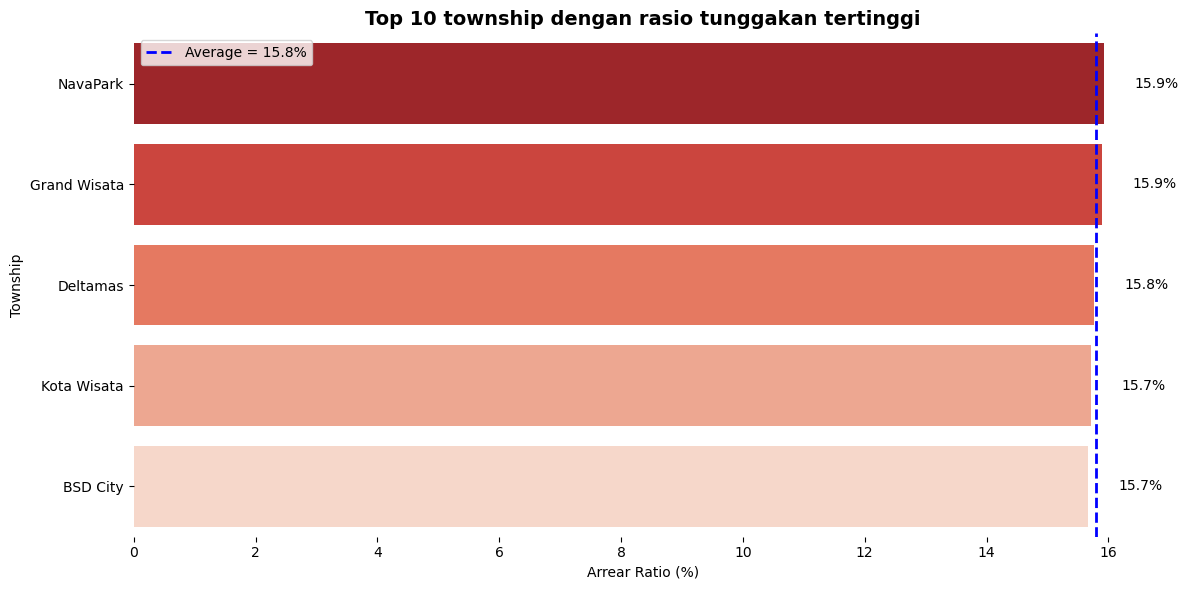

In [277]:
# Visulisasi

# Ambil Top 10 township dengan rasio tunggakan tertinggi
top10 = township_arrear.sort_values(
    by="arrear_ratio",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top10,
    x="arrear_ratio",
    y=top10.index,
    palette="Reds_r"
)

# Tambahkan label persentase pada setiap bar
for i, value in enumerate(top10["arrear_ratio"]):
    ax.text(
        value + 0.5,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=10
    )

# Garis rata-rata
avg_ratio = township_arrear["arrear_ratio"].mean()

plt.axvline(
    avg_ratio,
    color="blue",
    linestyle="--",
    linewidth=2,
    label=f"Average = {avg_ratio:.1f}%"
)

plt.title(
    "Top 10 township dengan rasio tunggakan tertinggi",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Arrear Ratio (%)")
plt.ylabel("Township")
plt.legend()

plt.tight_layout()
plt.show()

**✍️ Analisis :**

- Visualisasi ini bertujuan mengidentifikasi township dengan persentase pelanggan yang memiliki tunggakan IPL tertinggi.

- Township dengan rasio terbesar merupakan area yang perlu diprioritaskan dalam strategi penagihan karena memiliki risiko tunggakan yang lebih tinggi dibandingkan township lainnya.

Rasio Tunggakan per Cluster

In [278]:
cluster_arrear = (df_master.groupby("cluster_category")
      .agg(
          total_unit=("unit_id","count"),
          total_arrear=("is_arrear","sum")
      )
)

cluster_arrear["arrear_ratio"] = (
    cluster_arrear["total_arrear"] /
    cluster_arrear["total_unit"]*100
)

cluster_arrear = cluster_arrear.sort_values(
    "arrear_ratio",
    ascending=False
)

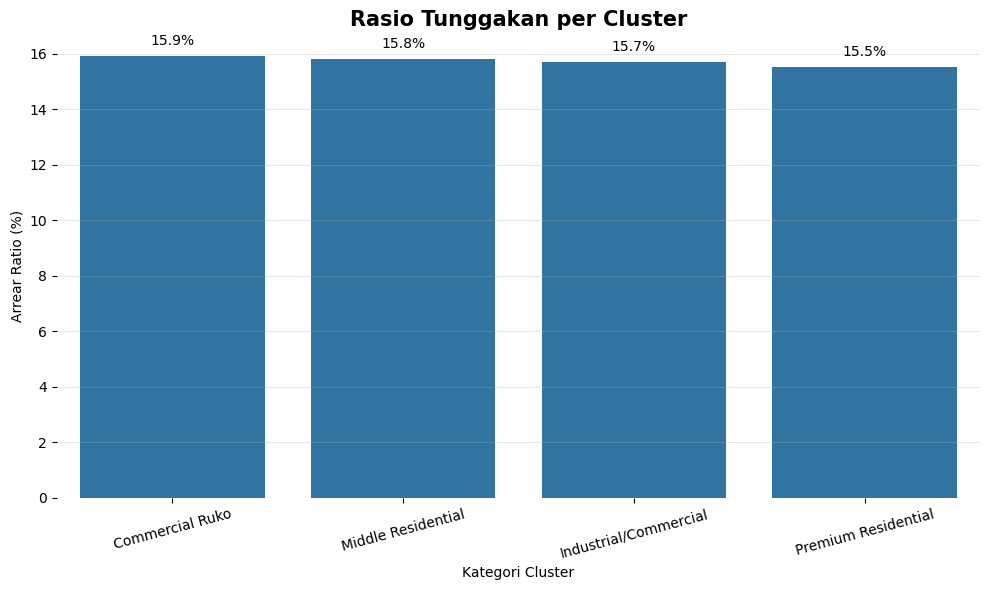

In [279]:
# Visualisasi
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=cluster_arrear,
    x="cluster_category",
    y="arrear_ratio",
)

for i,v in enumerate(cluster_arrear["arrear_ratio"]):
    ax.text(i,v+0.4,f"{v:.1f}%",ha="center")

plt.title(
    "Rasio Tunggakan per Cluster",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Kategori Cluster")
plt.ylabel("Arrear Ratio (%)")

plt.grid(axis="y",alpha=.3)

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

**✍️ Analisis :**

Visualisasi digunakan untuk mengetahui kategori cluster yang memiliki proporsi tunggakan IPL terbesar sehingga dapat menjadi fokus evaluasi pengelolaan kawasan.

Vacant vs Arrear

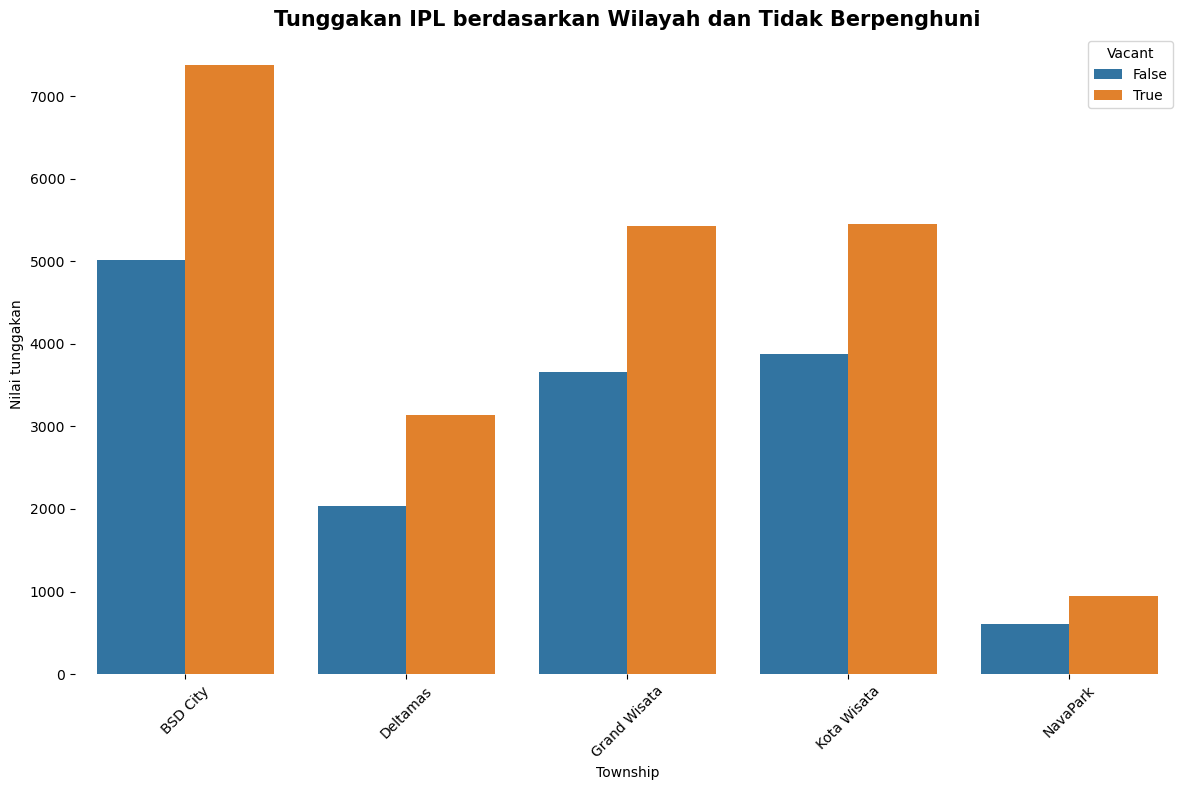

In [280]:
vacant = (
    df_master[df_master["is_arrear"]==True]
    .groupby(["township_name","is_vacant"])
    .size()
    .reset_index(name="Total")
)
plt.figure(figsize=(12,8))

sns.barplot(
    data=vacant,
    x="township_name",
    y="Total",
    hue="is_vacant"
)

plt.xticks(rotation=45)

plt.title(
    "Tunggakan IPL berdasarkan Wilayah dan Tidak Berpenghuni",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Township")
plt.ylabel("Nilai tunggakan")

plt.legend(title="Vacant")

plt.tight_layout()

plt.show()

**✍️ Analisis :**

Visualisasi ini memperlihatkan distribusi rumah kosong (Vacant) dan rumah terisi terhadap status tunggakan IPL. Apabila proporsi rumah kosong yang menunggak lebih tinggi dibandingkan rumah terisi, maka status hunian dapat menjadi salah satu indikator risiko keterlambatan pembayaran.

Payment Status berdasarkan township yang tidak berpenghuni 

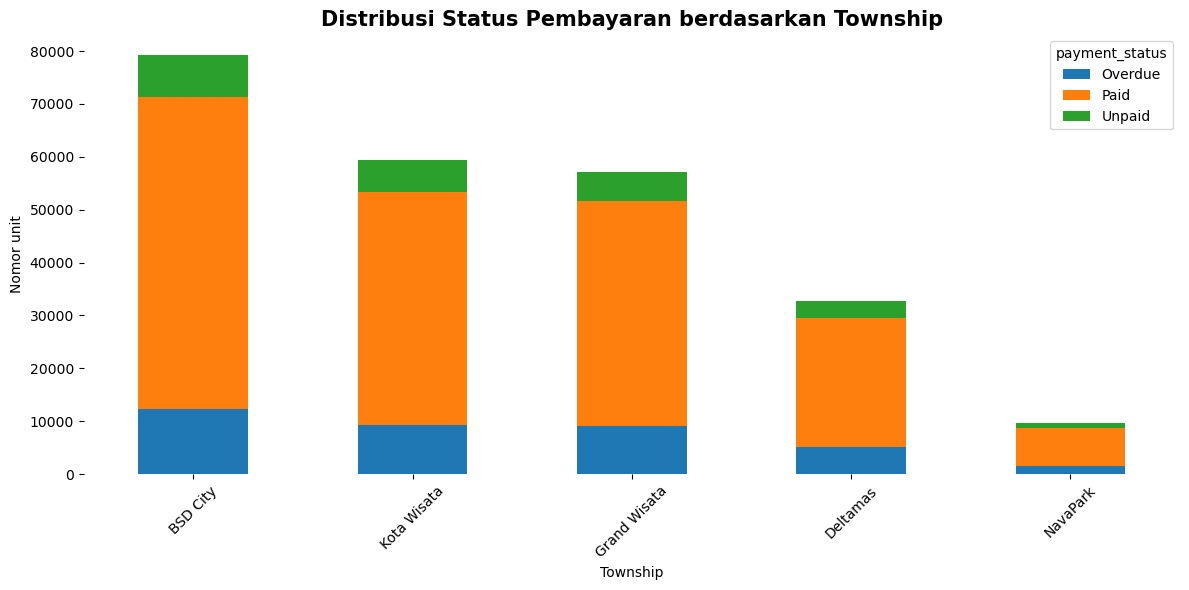

In [281]:
pivot = pd.crosstab(
    df_master["township_name"],
    df_master["payment_status"]
)

pivot = pivot.sort_values(
    by="Overdue",
    ascending=False
)

pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title(
    "Distribusi Status Pembayaran berdasarkan Township",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Nomor unit")
plt.xlabel("Township")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

**✍️ Analisis :**

- Visualisasi Vacant vs Arrear per Township digunakan untuk membandingkan jumlah unit yang memiliki tunggakan IPL (is_arrear = True) berdasarkan status hunian (Vacant dan Occupied) pada setiap township.

- Melalui visualisasi ini, dapat diidentifikasi township yang memiliki jumlah tunggakan tertinggi sekaligus melihat apakah tunggakan tersebut lebih banyak berasal dari rumah yang kosong (Vacant) atau rumah yang masih dihuni (Occupied).

**Hipotesis**

H0: Tidak terdapat hubungan signifikan antara status hunian (is_vacant) dan status tunggakan IPL (is_arrear).

Ha: Terdapat hubungan signifikan antara status hunian (is_vacant) dan status tunggakan IPL (is_arrear).

In [282]:
# Uji Chi Square
from scipy.stats import chi2_contingency
import pandas as pd

# Tabel kontingensi
contingency = pd.crosstab(
    df_master["is_vacant"],
    df_master["is_arrear"]
)

chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-Square Statistic : {chi2:.3f}")
print(f"Degrees of Freedom   : {dof}")
print(f"P-value              : {p:.5f}")

Chi-Square Statistic : 29051.447
Degrees of Freedom   : 1
P-value              : 0.00000


**Interpretasi**

Hasil uji Chi-Square menunjukkan nilai p-value < 0,05, sehingga H0 ditolak. Artinya, terdapat hubungan yang signifikan antara status hunian (is_vacant) dan status tunggakan IPL (is_arrear). Berdasarkan analisis rasio tunggakan, township yang memiliki rasio tunggakan tertinggi didominasi oleh rumah yang berstatus Vacant. Dapat disimpulkan bahwa unit yang tidak dihuni memiliki kecenderungan lebih tinggi mengalami tunggakan dibandingkan unit yang masih ditempati.

### **4.2 Total amount menunggak > 6 bulan**

In [283]:
# melihat jumlah masing-masing payment status
payment_summary = (
    df_master["payment_status"]
    .value_counts()
)

payment_summary

payment_status
Paid       176980
Overdue     37543
Unpaid      23782
Name: count, dtype: int64

In [284]:
# Menghitung lama tunggakan

df_master["billing_month"] = pd.to_datetime(df_master["billing_month"])
df_master = df_master.sort_values(
    ["unit_id", "billing_month"]
)


In [285]:
# tandai tagihan yang belom bayar
df_master["is_unpaid"] = (
    df_master["payment_status"]
    .isin(["Unpaid", "Overdue"])
)

In [286]:
# Filter tagihan yang menunggak
arrear_df = df_master[
    df_master["payment_status"].isin(["Unpaid", "Overdue"])
]

In [287]:
# Hitung jumlah bulan yang menunggak per unit
arrear_count_per_unit = (
    arrear_df
    .groupby("unit_id")
    .size()
    .reset_index(name="overdue_months")
)

arrear_count_per_unit.head()

,unit_id,overdue_months
0,UNT-00001,2
1,UNT-00002,3
2,UNT-00003,6
3,UNT-00004,2
4,UNT-00005,2


In [288]:
# Filter unit yang menunggak > 6 bulan
arrear_6 = arrear_count_per_unit[
    arrear_count_per_unit["overdue_months"] >= 6
]

arrear_6.head()

,unit_id,overdue_months
2,UNT-00003,6
5,UNT-00006,7
20,UNT-00025,7
25,UNT-00030,6
38,UNT-00044,9


In [289]:
df_master["over_6_months"] = (
    df_master["unit_id"].isin(
        arrear_6["unit_id"]))
df_master["over_6_months"]

136088    False
204723    False
207873    False
185899    False
122921    False
          ...  
188154    False
203919    False
226518    False
199166    False
219059    False
Name: over_6_months, Length: 238305, dtype: bool

In [290]:
df_master["over_6_months"].value_counts()

over_6_months
False    209385
True      28920
Name: count, dtype: int64

In [291]:
arrear_count_per_unit.sort_values(
    "overdue_months",
    ascending=False
).head(10)

,unit_id,overdue_months
14261,UNT-16762,13
2949,UNT-03485,13
9618,UNT-11342,13
13345,UNT-15687,12
13982,UNT-16435,12
16942,UNT-19925,12
13930,UNT-16378,12
7305,UNT-08625,12
14591,UNT-17148,12
1231,UNT-01435,12


In [292]:
print("Total unit:", df_master["unit_id"].nunique())

print("Unit dengan tunggakan >=6 bulan:",
      arrear_6["unit_id"].nunique())

Total unit: 25000
Unit dengan tunggakan >=6 bulan: 2592


In [293]:
df_master = df_master.merge(
    arrear_count_per_unit,
    on="unit_id",
    how="left"
)

In [294]:
df_master[[
    "billing_month",
    "overdue_months",
    "over_6_months"
]].head()

,billing_month,overdue_months,over_6_months
0,2020-07-01,2.0,False
1,2023-02-01,2.0,False
2,2023-08-01,2.0,False
3,2023-10-01,2.0,False
4,2023-11-01,2.0,False


In [295]:
# Menghitung total nilai invoice yang berstatus "Paid"
paid_amount = df_master[df_master['payment_status'] == 'Paid']['total_amount'].sum()

print(f"Total Paid Amount: Rp {paid_amount:,.0f}")

Total Paid Amount: Rp 239,308,192,500


In [296]:
# Menghitung total nilai invoice yang berstatus "Overdue"
paid_amount = df_master[df_master['payment_status'] == 'Overdue']['total_amount'].sum()

print(f"Total Overdue Amount: Rp {paid_amount:,.0f}")

Total Overdue Amount: Rp 48,490,080,000


In [297]:
# Menghitung total nilai invoice yang berstatus "Unpaid"
paid_amount = df_master[df_master['payment_status'] == 'Unpaid']['total_amount'].sum()

print(f"Total Unpaid Amount: Rp {paid_amount:,.0f}")

Total Unpaid Amount: Rp 30,423,007,500


**Total Nilai Outstanding (Overdue + Unpaid)**

In [298]:
# Menghitung total nilai invoice outstanding (overdue + unpaid)
bad_debt_amount = df_master[
    df_master['payment_status'].isin(['Overdue', 'Unpaid'])
]['total_amount'].sum()

print(f"Total Outstanding Amount: Rp {bad_debt_amount:,.0f}")

Total Outstanding Amount: Rp 78,913,087,500


In [299]:
# Jumlah unit outstanding amount > 6 bulan 
arrear_count_per_unit = df_master.groupby("unit_id")["is_arrear"].sum()
chronic_units = arrear_count_per_unit[arrear_count_per_unit >= 6].index

print(f"Jumlah unit kronis menunggak (>= 6 invoice Unpaid/Overdue): {len(chronic_units):,} dari {df_master['unit_id'].nunique():,} unit")

Jumlah unit kronis menunggak (>= 6 invoice Unpaid/Overdue): 875 dari 25,000 unit


In [300]:
# Menghitung Total Pendapatan yang hilang
lost_revenue = df_master[df_master["unit_id"].isin(chronic_units) & df_master["is_arrear"]]["total_amount"].sum()
print(f"Total potensi pendapatan hilang atau tertunda dari unit-unit ini: Rp {lost_revenue:,.0f}")

Total potensi pendapatan hilang atau tertunda dari unit-unit ini: Rp 6,794,037,500


**Persentase unit vacant**

In [301]:
# Persentase unit rumah yang berstatus kosong/vacant
pct_chronic_vacant = df_units.set_index('unit_id').loc[chronic_units, 'is_vacant'].mean()
print(f"{pct_chronic_vacant:.1%} berstatus Vacant")

99.8% berstatus Vacant


In [302]:
print(f"Jumlah unit kronis : {len(chronic_units):,}")
print(f"Total outstanding : Rp {lost_revenue:,.0f}")
print(f"Rata-rata tunggakan per unit : Rp {lost_revenue/len(chronic_units):,.0f}")

Jumlah unit kronis : 875
Total outstanding : Rp 6,794,037,500
Rata-rata tunggakan per unit : Rp 7,764,614


**✍️ Analisis :**
- Terdapat 875 dari 25.000 unit yang menunggak >= 6 bulan berturut-turut dengan nilai sebesar Rp 6,794,037,500. Angka ini mendominasi sebesar 62,3% dari total seluruh piutang IPL yang belum tertagih.
- Dampak Bisnis : Township harus tetap membayar biaya perawatan fasilitas seperti :
    - Security
    - Garden Maintenance
    - Cleaning Service
    - Clubhouse
    - Street Lighting
- untuk unit yang tidak membayar iuran selama setengah tahun yang menyebabkan bengkaknya biaya operasional 
- Tunggakan >= 6 bulan memiliki probabilitas penagihan yang sangat rendah jika menggunkan metode biasa dikarenakan berdasarkan temuan data sebelumnya sebagian besar unit yang menunggak berasal dari rumah yang berstatus kosong atau vacant
- Resiko : Biaya Operasional membengkak dan kerugian untuk perusahaan
- Keputusan penanganan per masalah: 
    - Stop Metode Penagihan Pasif: Rekomendasikan kepada tim bisnis untuk segera membentuk Special Task Force (Tim Gugus Tugas Khusus) guna mengejar data kontak pemilik langsung (bukan alamat unit) melalui database legalitas/sales saat transaksi awal.
    - Program Pemutihan denda / Settlement: Berikan opsi program restrukturisasi khusus (misal: hapus denda keterlambatan jika bersedia melunasi pokok iuran dalam waktu 30 hari) untuk segera mencairkan dana macet sebesar Rp 6,79 Miliar ini ke dalam arus kas perusahaan.

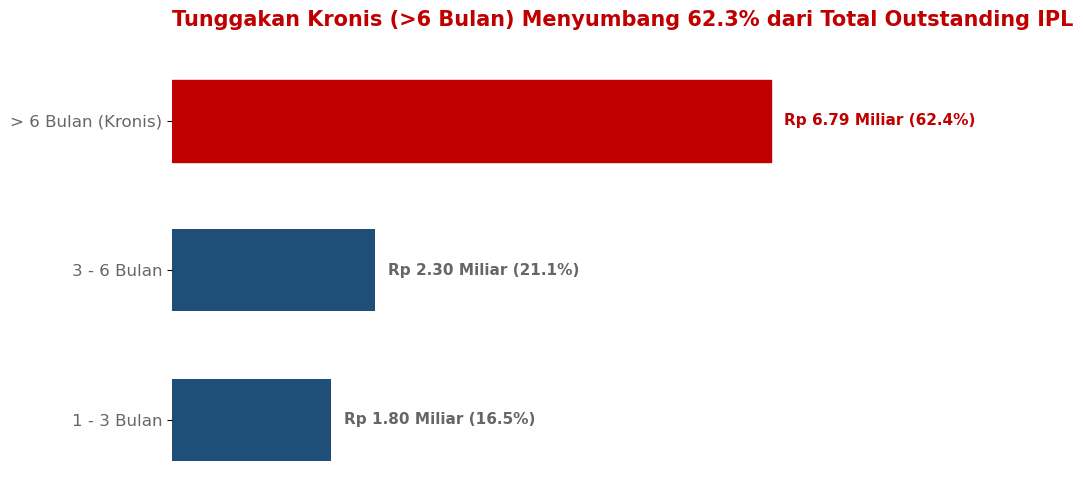

In [303]:
PRIMARY      = '#1F4E79'  
ALERT_COLOR  = '#C00000'  
GRAY         = '#666666'  
LIGHT_GRAY   = '#F5F5F5'  


plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.bottom'] = False


aging_data = {
    'Durasi Tunggakan': ['1 - 3 Bulan', '3 - 6 Bulan', '> 6 Bulan (Kronis)'],
    'Nilai Outstanding (Miliar)': [1.8, 2.3, 6.79] 
}

df_aging = pd.DataFrame(aging_data)


fig, ax = plt.subplots(figsize=(10, 5))


bars = ax.barh(
    df_aging['Durasi Tunggakan'], 
    df_aging['Nilai Outstanding (Miliar)'], 
    color=PRIMARY, 
    height=0.55
)


bars[2].set_color(ALERT_COLOR)


total_outstanding = df_aging['Nilai Outstanding (Miliar)'].sum()

for bar in bars:
    width = bar.get_width()
    percentage = (width / total_outstanding) * 100
    
    label_text = f'Rp {width:,.2f} Miliar ({percentage:.1f}%)'
    
 
    text_color = ALERT_COLOR if width == 6.79 else GRAY
    
    ax.text(
        width + 0.15,                       
        bar.get_y() + bar.get_height()/2,   
        label_text, 
        va='center', 
        ha='left', 
        fontsize=11, 
        fontweight='bold', 
        color=text_color
    )


ax.set_title(
    'Tunggakan Kronis (>6 Bulan) Menyumbang 62.3% dari Total Outstanding IPL', 
    fontsize=15, 
    fontweight='bold', 
    pad=25, 
    color=ALERT_COLOR, 
    loc='left'
)


ax.set_xlabel('Nilai Outstanding (dalam Miliar Rupiah)', fontsize=11, color=GRAY, labelpad=10)
ax.set_xlim(0, 9.0) 
ax.get_xaxis().set_visible(False) 
ax.tick_params(axis='y', which='major', labelsize=12, labelcolor=GRAY)

plt.tight_layout()


plt.savefig('outstanding_aging_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

#### 💡 Insight

**📊 Observasi:**
- Tunggakan Kronis lebih dari 6 bulan berturut-turut menyumbang 62,3% dari total outstanding IPL. 
- Nilai total outstanding terbesar jauh lebih tinggi dari 1-3 bulan maupun 3-6 bulan yaitu sebesar Rp 6,79 Milliar.

**🔍 Interpretasi:**
- Mayoritas piutang telah masuk dalam high-risk receivable.
- Semakin lama umur piutang maka akan makin kecil peluang pembayaran karena pemilik rumah cenderung semakin sulit untuk dihubungi atau kehilangan motivasi untuk memlunasi piutang yang ada.

**📌 Rekomendasi:**
- Pisahkan strategi collection berdasarkan umur piutang:
    * 1-3 bulan -> Reminder otomatis
    * 3-6 bulan -> Telepon dan negosiasi pembayaran
    * lebih dari 6 bulan -> Penanganan khusus melalui collection intensif atau legal recovery

**Hipotesis**

H0: Tidak terdapat perbedaan nilai tagihan (total_amount) antara pelanggan yang menunggak lebih dari enam bulan dan pelanggan yang tidak menunggak lebih dari enam bulan.

Ha: Terdapat perbedaan nilai tagihan (total_amount) antara pelanggan yang menunggak lebih dari enam bulan dan pelanggan yang tidak menunggak lebih dari enam bulan.

**Uji Mann-Whitney**

In [304]:
from scipy.stats import mannwhitneyu

# Kelompok 1: Overdue dan Unpaid
group1 = df_master.loc[
    (df_master["payment_status"].isin(["Overdue", "Unpaid"])) &
    (df_master["over_6_months"]),
    "total_amount"
]

# Kelompok 2: Paid
group2 = df_master.loc[
    df_master["payment_status"] == "Paid",
    "total_amount"
]


stat, p = mannwhitneyu(
    group1,
    group2,
    alternative="two-sided"
)

print(f"U Statistic : {stat}")
print(f"P-value     : {p:.3e}")

U Statistic : 1179616643.5
P-value     : 0.000e+00


**Interpretasi**

Hasil uji Mann–Whitney U menunjukkan nilai statistik sebesar 1179616643.5 dengan p-value < 0,001, sehingga H₀ ditolak. Hal ini menunjukkan bahwa terdapat perbedaan yang signifikan pada nilai tagihan (total_amount) antara pelanggan yang menunggak lebih dari enam bulan dan pelanggan lainnya. Dengan demikian, pelanggan dengan tunggakan lebih dari enam bulan memiliki karakteristik nilai tagihan yang berbeda secara signifikan dan menjadi kontributor utama terhadap potensi pendapatan yang tertunda.

### 4.3 **Analysis transaksi & payment method**

In [305]:
print("Before:")
print(df_ipl["payment_method"].value_counts(dropna=False))
print("\nAfter:")
print(df_ipl["payment_method_clean"].value_counts(dropna=False))

Before:
payment_method
NaN                    90278
toped                  23449
KAS                    23438
Cash                   23370
cc                     23302
Credit Card            23267
bca va                 23242
Tokopedia              23238
BCA Virtual Account    23216
VA BCA                 23200
Name: count, dtype: int64

After:
payment_method_clean
NaN                    90278
BCA Virtual Account    69658
Cash                   46808
Tokopedia              46687
Credit Card            46569
Name: count, dtype: int64


**✍️ Analisis :**
- Terdapat berbagai variasi payment method, padahal ada metode yang sama hanya berbeda ditulisan
- Dampak Bisnis : Tim Finance harus terus melakukan Matching, Cleaning dan Rekonsiliasi manual setiap akhir bulan
- Resiko : Salah klasifikasi transaksi, salah laporan pembayaran, dan closing bulanan lebih lama
- Keputusan penanganan per masalah: Buat master payment method, selain itu gunakan dropdown pada ERP


### 4.4 **Missing Contact number**

In [306]:
df_units['contact_number_missing'] = df_units['contact_number'].isnull()

print(f"{df_units['contact_number_missing'].sum():,} units missing a phone number "
      f"({df_units['contact_number_missing'].mean():.1%})")

5,000 units missing a phone number (20.0%)


**✍️ Analisis :**
- Terdapat 20% unit atau sebanyak 5000 unit yang tidak memiliki nomor telepon yang valid 
- Tidak mengubah atau menghapus kolom no telepon yang kosong karena datanya kategorikal (kualitatif)
- Dampak Bisnis :
    - Ketika terjadi:
        - IPL Overdue
        - Tagihan air menunggak
        - Komplain pelanggan
    - Tim Collection tidak dapat melakukan:
        - WhatsApp Blast
        - Reminder
        - Telemarketing
        - Follow Up
- Resiko : Jika mayoritas unit tersebut adalah rumah vacant, tunggakan akan terus bertambah karena tidak ada penghuni yang mengingatkan pemilik
- Keputusan penanganan per masalah: 
    - Wajibkan update nomor telepon pada pembayaran IPL atau pembayaran air

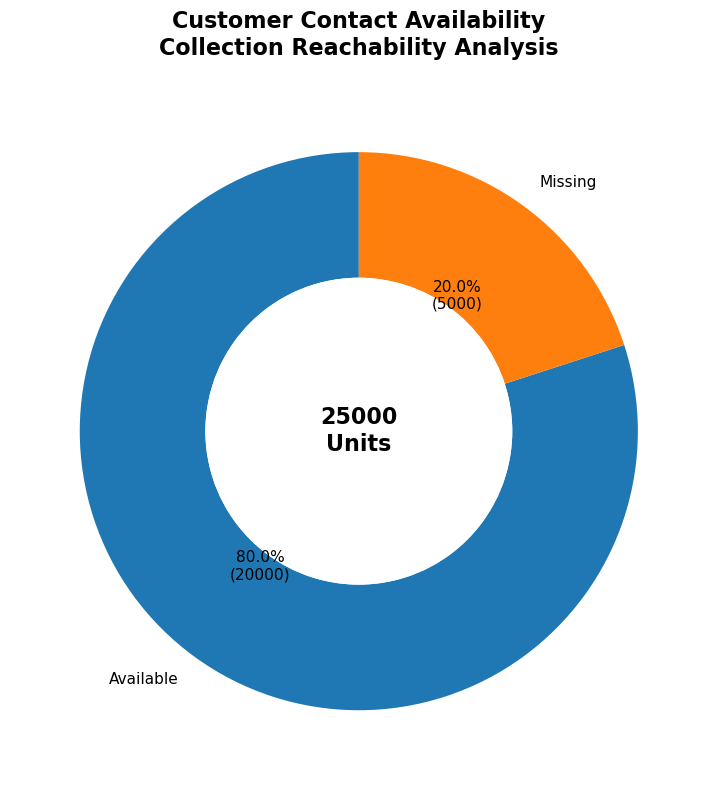

In [307]:
# Visualization
contact = pd.Series({
    "Available": df_units["contact_number"].notna().sum(),
    "Missing": df_units["contact_number"].isna().sum()
})


fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    contact.values,
    labels=contact.index,
    autopct=lambda pct: f'{pct:}%\n({int(round(pct/100*contact.sum()))})',
    startangle=90,
    wedgeprops=dict(width=0.45),  
    textprops={'fontsize': 11}
)

centre_circle = plt.Circle((0, 0), 0.55, fc='white')
fig.gca().add_artist(centre_circle)

ax.text(
    0, 0,
    f'{contact.sum()}\nUnits',
    ha='center',
    va='center',
    fontsize=16,
    fontweight='bold'
)

plt.title(
    "Customer Contact Availability\nCollection Reachability Analysis",
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

#### 💡 Insight

**📊 Observasi:**
- Terdapat 20% unit atau sebanyak 5000 unit yang tidak memiliki nomor telepon pemilik yang valid.

**🔍 Interpretasi:**
- Unit yang tidak memiliki kontak pemilik yang valid akan menurunkan efetivitas aktivitas collection.
- Pemilik dengan nomor yang tidak valid atau tidak ada berpotensi menjadi kelompok yang berisiko tinggi mengalami keterlambatan pembayarn karena sulit untuk dihubungi.

**📌 Rekomendasi:**
- Jadikan kontak pelanggan sebagai KPI administrasi pelanggan.
- Lakukan validasi dan pembaharuan data secara berkala.
- Wajibkan verifikasi nomor telepon pelanggan saat melakukan transaksi pelayanan pelanggan.


### 4.5 **Anomali payment date & handover date**


In [308]:
print(f"Invoices Paid before handover: {n_error:,} out of {n_paid:,} Paid invoices ({n_error/n_paid:.2%})")

print(f"\nUnits affected: {n_units_affected:,}")
print(f"\nTotal value of these anomalous transactions: Rp {error_value:,.0f}")

print(df_ipl_clean.loc[df_ipl_clean["is_logical_error"],
                  ["unit_id", "billing_month", "payment_date", "handover_date", "total_amount"]].head(10))

Invoices Paid before handover: 6,210 out of 176,980 Paid invoices (3.51%)

Units affected: 5,510

Total value of these anomalous transactions: Rp 8,266,960,000
         unit_id billing_month payment_date handover_date  total_amount
61358  UNT-20834       2020-05   2020-05-02    2021-06-06    76492500.0
61376  UNT-23534       2019-01   2019-01-28    2020-02-18      627500.0
61385  UNT-20049       2020-04   2020-04-16    2021-05-30      860000.0
61389  UNT-21228       2021-04   2021-04-04    2022-09-05      425000.0
61393  UNT-01322       2019-02   2019-02-23    2020-12-12     1052500.0
61462  UNT-10371       2020-10   2020-10-22    2022-01-29      642500.0
61482  UNT-11286       2019-11   2019-11-06    2021-10-13     1687500.0
61505  UNT-19742       2018-08   2018-08-31    2020-01-08      627500.0
61512  UNT-14833       2020-01   2020-01-20    2021-03-22      545000.0
61573  UNT-15591       2020-04   2020-04-03    2021-07-29     1037500.0


**✍️ Analisis :**
- Terdapat 6210 transaksi "Paid" sebelum handover date yang artinya sistem mengijinkan rumah belum diserahterimakan tetapi sudah membayar IPL yang secara logika tidak mungin terjadi
- Dampak Bisnis : Laporan Collection menjadi tidak valid, saat terjadi audit eksternal revenue recognition dipertanyakan karena mendahului legalitas serah terima aset
- Resiko : Menurunnya kepercayaan pelanggan yang menerima tagihan sebelum rumah diterima
- Keputusan penanganan per masalah: 
    - Tambahkan validasi rule di database ERP : IF payment_date < handover_date THEN REJECT_TRANSACTION_STATUS = 'Paid'
    - Tim Finance perlu memeriksa ulang invoice tersebut yang memiliki kemungkinan uang muka (down payment / deposit IPL dimuka) yang salah input atau salah masuk akun pendapatan reguler.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21240\1047861363.py:82: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_21240\1047861363.py:83: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.savefig('erp_logic_error_clean.png', dpi=300, bbox_inches='tight')
c:\Users\LENOVO\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


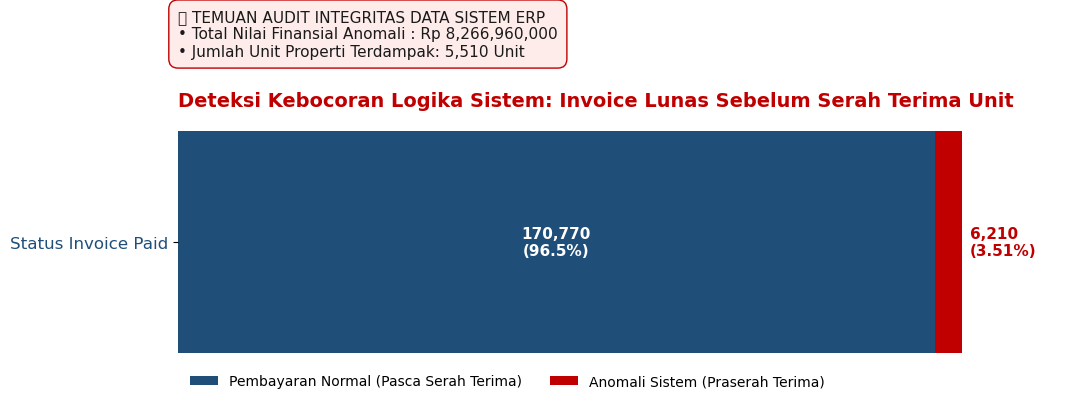

In [309]:
# Visualization
PRIMARY      = '#1F4E79'  
ALERT_COLOR  = '#C00000'  
GRAY         = '#666666'  


plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.bottom'] = False


df_ipl_clean["payment_date"] = pd.to_datetime(df_ipl_clean["payment_date"])
df_units["handover_date"] = pd.to_datetime(df_units["handover_date"])

df_ipl_clean = df_ipl_clean.drop(columns=["handover_date"], errors="ignore")
df_ipl_clean = df_ipl_clean.merge(df_units[["unit_id", "handover_date"]], on="unit_id", how="left")

df_ipl_clean["is_logical_error"] = (
    (df_ipl_clean["payment_status"] == "Paid") &
    (df_ipl_clean["payment_date"] < df_ipl_clean["handover_date"])
)

n_error = df_ipl_clean["is_logical_error"].sum()
n_paid = (df_ipl_clean["payment_status"] == "Paid").sum()
n_normal = n_paid - n_error
error_rate = n_error / n_paid

error_value = df_ipl_clean.loc[df_ipl_clean["is_logical_error"], "total_amount"].sum()
n_units_affected = df_ipl_clean.loc[df_ipl_clean["is_logical_error"], "unit_id"].nunique()


fig, ax = plt.subplots(figsize=(11, 5))


bar_normal = ax.barh(['Status Invoice Paid'], [n_normal], color=PRIMARY, height=0.4, label='Pembayaran Normal (Pasca Serah Terima)')

bar_error = ax.barh(['Status Invoice Paid'], [n_error], left=[n_normal], color=ALERT_COLOR, height=0.4, label='Anomali Sistem (Praserah Terima)')


ax.text(
    n_normal / 2, 0, 
    f'{n_normal:,}\n({(n_normal/n_paid):.1%})', 
    va='center', ha='center', fontsize=11, fontweight='bold', color='white'
)

ax.text(
    n_paid + (n_paid * 0.01), 0, 
    f'{n_error:,}\n({error_rate:.2%})', 
    va='center', ha='left', fontsize=11, fontweight='bold', color=ALERT_COLOR
)


info_box_text = (
    f"🚨 TEMUAN AUDIT INTEGRITAS DATA SISTEM ERP\n"
    f"• Total Nilai Finansial Anomali : Rp {error_value:,.0f}\n"
    f"• Jumlah Unit Properti Terdampak: {n_units_affected:,} Unit"
)

ax.text(
    0, 0.42, info_box_text, 
    fontsize=11, color='#1A1A1A', weight='medium',
    va='top', ha='left',
    bbox=dict(boxstyle="round,pad=0.6", facecolor='#FEECEB', edgecolor=ALERT_COLOR, linewidth=1)
)


ax.set_title(
    "Deteksi Kebocoran Logika Sistem: Invoice Lunas Sebelum Serah Terima Unit", 
    fontsize=14, fontweight='bold', pad= 10, color=ALERT_COLOR, loc='left'
)

ax.get_xaxis().set_visible(False)
ax.tick_params(axis='y', which='major', labelsize=12, labelcolor=PRIMARY)

ax.set_xlim(0, n_paid * 1.15)


ax.legend(loc='lower left', bbox_to_anchor=(0, -0.15), ncol=2, frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig('erp_logic_error_clean.png', dpi=300, bbox_inches='tight')
plt.show()

#### 💡 Insight

**📊 Observasi:**
- Ditemukan transaksi berstatus "Paid" yang terjadi, tetapi tanggal pembayarannya lebih awal daripada tanggal serah terima unit.

**🔍 Interpretasi:**
- Kondisi ini tidak mungkin secara logika bisnis dan mengindikasikan adanya masalah kualitas data, kesalah input atau sinkronisasi antar sistem.

**📌 Rekomendasi:**
- Terapkan validasi otomatis pada sistem agar payment date tidak boleh lebih awal dari handover date.
- Audit seluruh transaksi yang teriidentifikasi.
- Bangun data quality monitoring sebagai bagian dari proses ETL

### **4.6 Outlier pada water usage**

In [ ]:
# Check jumlah outlier
df_ipl_clean["water_usage_flag"] = df_ipl["water_usage_flag"]

print(df_ipl_clean['water_usage_flag'].value_counts())
print(f"\nTotal baris anomali: {(df_ipl['water_usage_flag'] != 'Normal').sum()} dari {len(df_ipl_clean)} ({(df_ipl_clean['water_usage_flag'] != 'Normal').mean():.2%})")

water_usage_flag
Normal                           235915
Negative (Input Error)             1214
Extreme Outlier (Human Error)      1176
Name: count, dtype: int64

Total baris anomali: 3000 dari 238305 (1.00%)


In [316]:
# Distribusi kategori penggunaan air
water_summary = (
    df_ipl_clean["water_usage_flag"]
    .value_counts()
    .reset_index()
)

water_summary.columns = ["Kategori", "Jumlah"]

water_summary["Persentase (%)"] = (
    water_summary["Jumlah"] /
    water_summary["Jumlah"].sum() * 100
).round(2)

water_summary

,Kategori,Jumlah,Persentase (%)
0,Normal,235915,99.00
1,Negative (Input Error),1214,0.51
2,Extreme Outlier (Human Error),1176,0.49


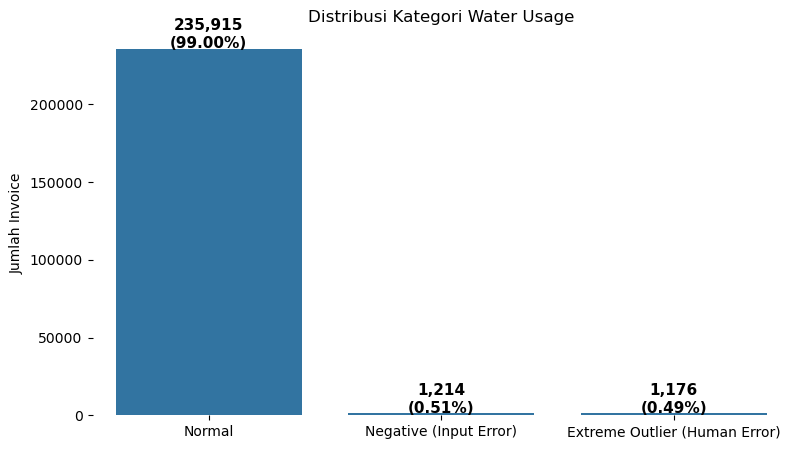

In [ ]:
# Visualisasi Distribusi Anomali Penggunaan Air

summary = (
    df_ipl_clean["water_usage_flag"]
    .value_counts()
    .reset_index()
)

summary.columns = ["Kategori", "Jumlah"]

summary["Persentase"] = (
    summary["Jumlah"] /
    summary["Jumlah"].sum()*100
)

plt.figure(figsize=(9,5))

ax = sns.barplot(
    data=summary,
    x="Kategori",
    y="Jumlah"
)

for i, row in summary.iterrows():
    ax.text(
        i,
        row["Jumlah"]+500,
        f'{row["Jumlah"]:,}\n({row["Persentase"]:.2f}%)',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Distribusi Kategori Water Usage")
plt.xlabel("")
plt.ylabel("Jumlah Invoice")

plt.show()

**Interpretasi:**

Sebagian besar data penggunaan air (99%) berada pada kategori normal. Namun ditemukan sekitar 1% data yang merupakan anomali, terdiri dari nilai negatif (indikasi kesalahan input sistem) dan nilai ekstrem 9999 (indikasi human error). Walaupun proporsinya kecil, anomali ini tetap perlu dibersihkan karena dapat memengaruhi analisis konsumsi air, estimasi tagihan, maupun model prediksi pembayaran.

In [317]:
# Crosstab terhadap Payment Status
table = pd.crosstab(
    df_ipl["water_usage_flag"],
    df_ipl["payment_status"]
)

table

payment_status,Overdue,Paid,Unpaid
water_usage_flag,,,
Extreme Outlier (Human Error),275,1019,187
Negative (Input Error),250,1086,183
Normal,52229,207617,37154


**Interpretasi**

Tabel kontingensi menunjukkan distribusi status pembayaran pada setiap kategori penggunaan air. Apabila proporsi pelanggan Unpaid atau Overdue lebih tinggi pada kelompok anomali dibanding kelompok normal, maka terdapat indikasi bahwa kualitas pencatatan penggunaan air dapat berkaitan dengan kondisi pembayaran.

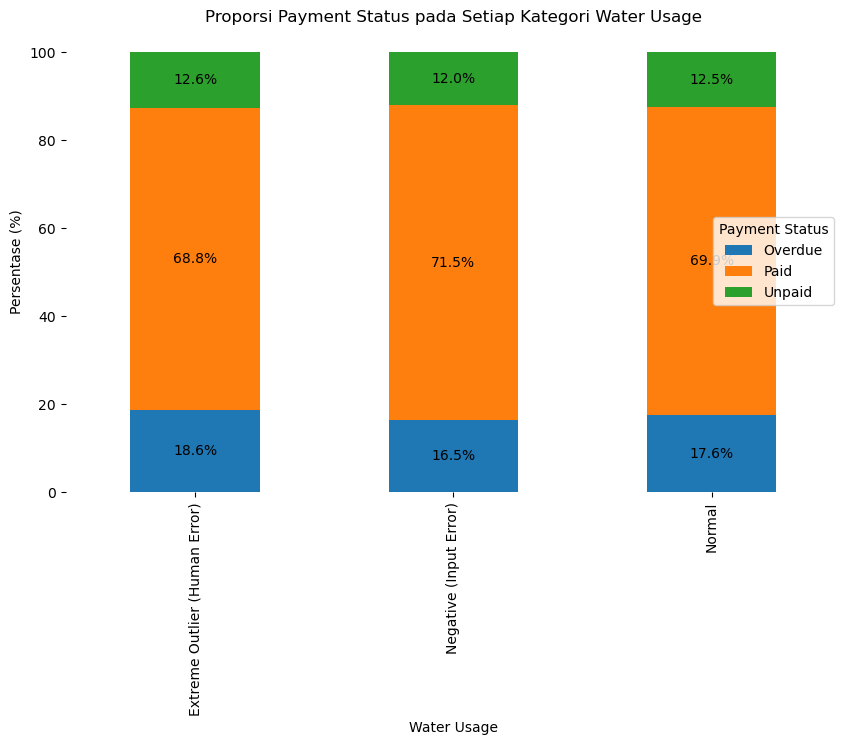

In [321]:
table_pct = pd.crosstab(
    df_ipl["water_usage_flag"],
    df_ipl["payment_status"],
    normalize="index"
)*100

ax = table_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Proporsi Payment Status pada Setiap Kategori Water Usage")
plt.ylabel("Persentase (%)")
plt.xlabel("Water Usage")

for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height()>0 else "" for v in c]
    ax.bar_label(c, labels=labels, label_type="center", fontsize=10)

plt.legend(title="Payment Status")

plt.show()

**Analisis:**

Terlihat bahwa komposisi ketiga status pembayaran pada setiap kategori penggunaan air relatif serupa. Persentase pelanggan yang melakukan pembayaran, menunggak, maupun belum membayar tidak menunjukkan perbedaan yang mencolok antara data penggunaan air normal dan data yang mengandung anomali.

**Uji Statistik**

Karena kedua variabel bersifat kategori, sehingga menggunakan Chi-Square Test of Independence.

Hipotesis

H0: Tidak terdapat hubungan signifikan antara kategori penggunaan air dan status pembayaran.

Ha: Terdapat hubungan signifikan antara kategori penggunaan air dan status pembayaran.

In [318]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df_ipl["water_usage_flag"],
    df_ipl["payment_status"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square :", round(chi2,3))
print("P-value    :", p)
print("Degree of Freedom :", dof)

if p < 0.05:
    print("Keputusan : Tolak H0")
else:
    print("Keputusan : Gagal Tolak H0")

Chi-square : 2.992
P-value    : 0.5592253629410717
Degree of Freedom : 4
Keputusan : Gagal Tolak H0


**Interpretasi:**

Hasil uji Chi-Square menunjukkan nilai p-value sebesar 0.56 > 0,05 sehingga H0 gagal ditolak. Artinya tidak terdapat bukti yang cukup signifikan bahwa kategori penggunaan air berhubungan dengan status pembayaran pelanggan.

**Insight Bisnis:**

- Sekitar 1% data penggunaan air teridentifikasi sebagai anomali (nilai negatif atau nilai ekstrem), sedangkan 99% data berada dalam kondisi normal.

- Hasil uji Chi-Square menunjukkan bahwa anomali penggunaan air tidak berhubungan secara signifikan dengan status pembayaran pelanggan. Dengan kata lain, pelanggan yang memiliki data penggunaan air anomali tidak lebih cenderung menjadi Paid, Overdue, maupun Unpaid dibandingkan pelanggan dengan data penggunaan air normal.

- Hal ini mengindikasikan bahwa anomali penggunaan air kemungkinan lebih disebabkan oleh kesalahan pencatatan (data quality issue) atau kesalahan input sistem, bukan karena perilaku pembayaran pelanggan.

- Oleh karena itu, perbaikan kualitas data tetap diperlukan agar proses billing lebih akurat. Namun, upaya peningkatan tingkat pembayaran sebaiknya difokuskan pada faktor lain yang lebih berpengaruh, seperti:
    - besarnya tagihan (total_amount)
    - lama tunggakan
    - status rumah kosong (is_vacant)
    - kategori cluster
    - metode pembayaran
    - faktor demografis pelanggan

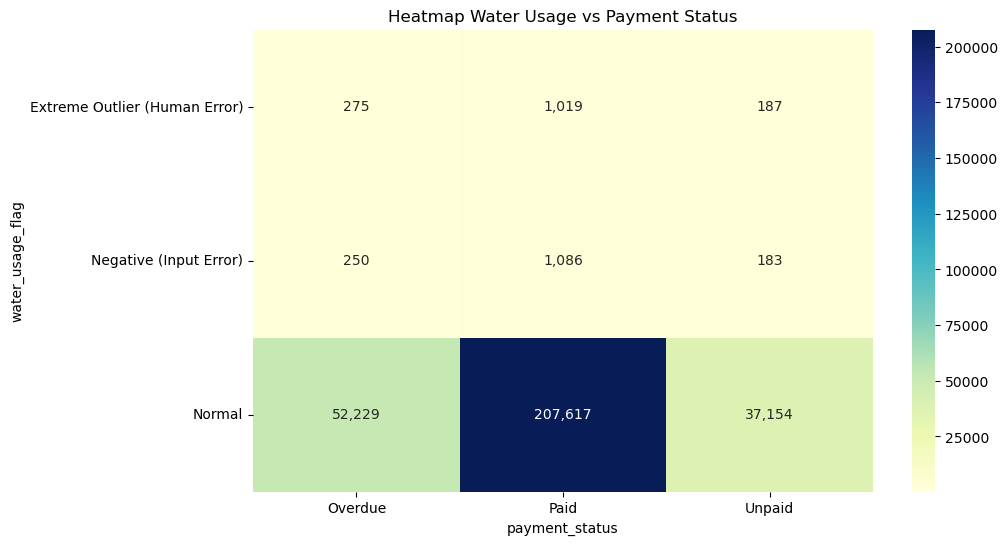

In [328]:
# Heatmap Water Usage vs Payment Status

plt.figure(figsize=(10,6))

sns.heatmap(
    table,
    annot=True,
    fmt=",",
    cmap="YlGnBu"
)

plt.title("Heatmap Water Usage vs Payment Status")

plt.show()

**Insight:**

Heatmap memperlihatkan bahwa jumlah terbesar berada pada kategori Normal, sedangkan dua kategori anomali yaitu input error dan human error memiliki jumlah observasi yang jauh lebih sedikit.

## **Section 5. Conclusion and Recommendation**

**5.1 Conclusion**

**5.2 Recommendation**